In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os, sys
import ast

# Get the absolute path to the src directory
src_path = os.path.abspath(os.path.join(os.getcwd(), "../"))
# Add src_path to the system path
sys.path.insert(0, src_path)
from utils import mappings

PUBLICATIONS_PATH = "../../data/raw/publication_meta/br_publication_meta.csv"
AUTHORS_PATH = "../../data/processed/6_authors.csv"

In [2]:
def create_interdisciplinary_heatmap(df, authors_df):
    """
    Creates a heatmap showing normalized counts of interdisciplinary collaborations between academic subfields.

    The heatmap shows:
    - ROWS: Publication subfields (excluding 'unknown')
    - COLUMNS: Author primary subfields (excluding 'unknown' and NA)
    - VALUES: Number of publications in subfield A (row) that have at least one author
              whose primary subfield is B (column), divided by the total number of authors in subfield B.

    Args:
        df (DataFrame): Publication metadata containing 'subfield' and 'authorships' columns.
        authors_df (DataFrame): Author information with 'id' and 'primary_subfield' columns.

    Returns:
        matplotlib.figure.Figure: The created heatmap figure.
    """

    # Create a mapping of author IDs to their primary subfields
    author_to_subfield = authors_df.set_index("id")["primary_subfield"].to_dict()

    # Process publication data
    df = df.copy()

    # Extract subfield display names from nested data structure
    df["subfield"] = df["subfield"].apply(
        lambda x: ast.literal_eval(x)["display_name"] if isinstance(x, str) else x
    )

    # Extract author IDs from authorships column
    df["author_ids"] = df["authorships"].apply(
        lambda x: [a["id"] for a in ast.literal_eval(x)] if isinstance(x, str) else x
    )

    # Get all unique valid subfields (excluding 'unknown' and NA)
    valid_author_subfields = authors_df.loc[
        (authors_df["primary_subfield"].notna())
        & (authors_df["primary_subfield"] != "unknown"),
        "primary_subfield",
    ].unique()

    valid_pub_subfields = df.loc[
        (df["subfield"].notna()) & (df["subfield"] != "unknown"), "subfield"
    ].unique()

    all_subfields = sorted(list(set(valid_author_subfields) | set(valid_pub_subfields)))

    # Initialize collaboration matrix (raw counts)
    collaboration_matrix = pd.DataFrame(0, index=all_subfields, columns=all_subfields)

    # Track which publications have already been counted for each subfield pair
    counted_publications = {
        (row, col): set() for row in all_subfields for col in all_subfields
    }

    # Fill the collaboration matrix
    for idx, publication in df.iterrows():
        pub_id = idx  # Use DataFrame index as publication ID
        pub_subfield = publication["subfield"]

        # Skip publications with unknown/NA subfield
        if pd.isna(pub_subfield) or pub_subfield == "unknown":
            continue

        # Get all unique valid subfields of authors in this publication
        author_subfields = set()
        for author_id in publication["author_ids"]:
            author_subfield = author_to_subfield.get(author_id)

            # Skip authors with unknown/NA primary subfield
            if pd.isna(author_subfield) or author_subfield == "unknown":
                continue

            author_subfields.add(author_subfield)

        # For each author subfield, increment the collaboration count if not already counted
        for author_subfield in author_subfields:
            # if author_subfield != pub_subfield:  # Avoid self-collaborations
            if pub_id not in counted_publications[(pub_subfield, author_subfield)]:
                collaboration_matrix.loc[pub_subfield, author_subfield] += 1
                counted_publications[(pub_subfield, author_subfield)].add(pub_id)

    # Normalize by the number of authors in each primary subfield (columns)
    author_counts = authors_df.loc[
        (authors_df["primary_subfield"].notna())
        & (authors_df["primary_subfield"] != "unknown"),
        "primary_subfield",
    ].value_counts()

    # Reindex author_counts to include all subfields in our matrix (fill missing with 0)
    author_counts = author_counts.reindex(all_subfields, fill_value=0)

    # Normalize the collaboration matrix by dividing each column by the corresponding author count
    normalized_matrix = collaboration_matrix.div(author_counts, axis=1)
    # Normalize the collaboration matrix by dividing each column by the corresponding author count.
    normalized_matrix = collaboration_matrix.div(author_counts, axis=1)

    # Create a display-friendly version with shortened names if available
    display_matrix = normalized_matrix.copy()

    # Optionally shorten the names if a mapping is provided
    try:
        display_matrix.index = display_matrix.index.map(
            lambda x: mappings.SUBFIELDS_SHORT.get(x, x)
        )
        display_matrix.columns = display_matrix.columns.map(
            lambda x: mappings.SUBFIELDS_SHORT.get(x, x)
        )
    except NameError:
        # If mappings not available, use original names
        pass

    # Set the visual style
    sns.set_theme(style="whitegrid", context="paper", font_scale=1.5)

    # Create the heatmap
    plt.figure(figsize=(8.5, 6))
    ax = sns.heatmap(
        display_matrix,
        annot=True,  # Show numbers in each cell
        fmt=".2f",  # Display as floating point with 2 decimals
        cmap="Blues",  # Blue color scheme - darker = more collaboration per author
        linewidths=0.5,
        cbar_kws={"label": "Normalized Publications per Author"},
        vmin=0,  # Minimum value for color scale
    )

    # Set labels and adjust layout
    plt.xlabel("Author Primary Subfield")
    plt.ylabel("Publication Subfield")
    plt.xticks(rotation=50, ha="right")  # Rotate column labels for readability
    plt.yticks(rotation=0)
    plt.tight_layout()

    # Save the figure
    plt.savefig(
        "../../results/figures/subfields_collabs_heatmap_normalized.pdf", format="pdf"
    )

    return ax.figure

In [3]:
publications_df = pd.read_csv(PUBLICATIONS_PATH)
authors_df = pd.read_csv(AUTHORS_PATH)

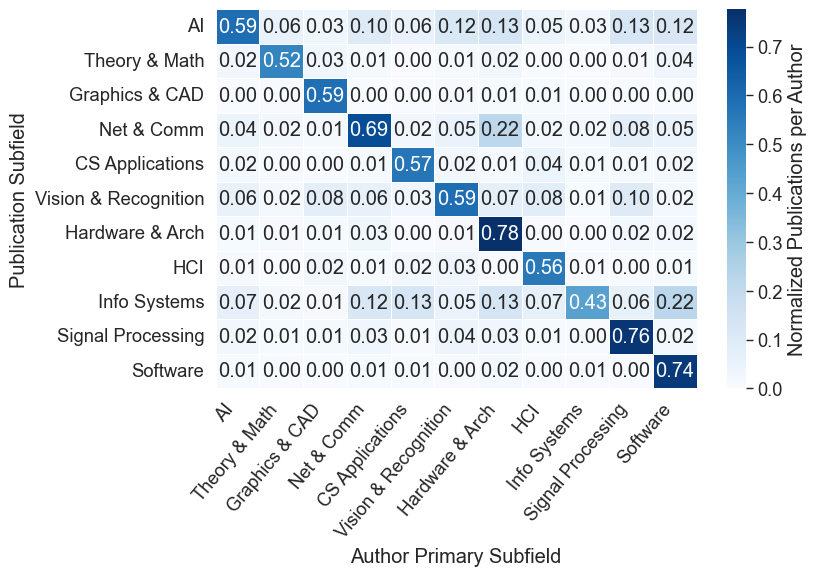

In [4]:
fig = create_interdisciplinary_heatmap(publications_df, authors_df)
plt.show()